In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

class VisualDomain:
    def __init__(self, start, end, label="", color="skyblue"):
        self.start = start
        self.end = end
        self.label = label
        self.color = color

class DomainTrack:
    def __init__(self, name, length):
        self.name = name
        self.length = length
        self.features = []

    def add_domain(self, start, end, label="", color="skyblue"):
        self.features.append(VisualDomain(start, end, label, color))

class LinearTrack:
    def __init__(self, name, values, plot_type='line', color='blue'):
        self.name = name
        self.values = np.array(values)
        self.length = len(values)
        self.plot_type = plot_type
        self.color = color

In [ ]:
class ProteinPlotter:
    def __init__(self):
        self.tracks = []

    def add_track(self, track):
        self.tracks.append(track)

    def plot(self, track_width=0.6, spacing=1.5):
        if not self.tracks:
            return
        
        fig, ax = plt.subplots(figsize=(len(self.tracks) * 2.5, 8))
        
        # We find the longest sequence to set the y-axis limit
        max_len = max(t.length for t in self.tracks)

        for i, track in enumerate(self.tracks):
            x_center = i * spacing
            
            # --- Draw DOMAIN tracks ---
            if isinstance(track, DomainTrack):
                # Draw the main vertical backbone
                ax.plot([x_center, x_center], [0, track.length], color='black', lw=1.5, zorder=1)
                
                for dom in track.features:
                    rect = patches.Rectangle(
                        (x_center - track_width/2, dom.start), # x, y
                        track_width,                           # width
                        dom.end - dom.start,                   # height
                        facecolor=dom.color, edgecolor='black', zorder=2
                    )
                    ax.add_patch(rect)
                    ax.text(x_center, (dom.start + dom.end)/2, dom.label, 
                            ha='center', va='center', rotation=90, fontsize=9)

            # --- Draw LINEAR tracks ---
            elif isinstance(track, LinearTrack):
                # We normalize the values to fit inside the track_width
                v_min, v_max = track.values.min(), track.values.max()
                # Avoid division by zero
                v_range = (v_max - v_min) if v_max != v_min else 1
                
                # Rescale data to be within [-track_width/2, +track_width/2]
                norm_data = ((track.values - v_min) / v_range - 0.5) * track_width
                x_values = x_center + norm_data
                y_values = np.arange(len(track.values))

                if track.plot_type == 'line':
                    ax.plot(x_values, y_values, color=track.color, lw=1.5)
                else: # Bar chart
                    ax.barh(y_values, norm_data, left=x_center, color=track.color, height=1.0)
                
                # Draw boundary lines for the linear track
                ax.axvline(x_center - track_width/2, color='gray', lw=0.5, ls='--')
                ax.axvline(x_center + track_width/2, color='gray', lw=0.5, ls='--')

        # Formatting
        ax.set_ylim(max_len, 0) # Flip axis so residue 0 is at the top
        ax.set_xticks([i * spacing for i in range(len(self.tracks))])
        ax.set_xticklabels([t.name for t in self.tracks])
        ax.set_ylabel("Residue Position")
        plt.tight_layout()
        plt.show()

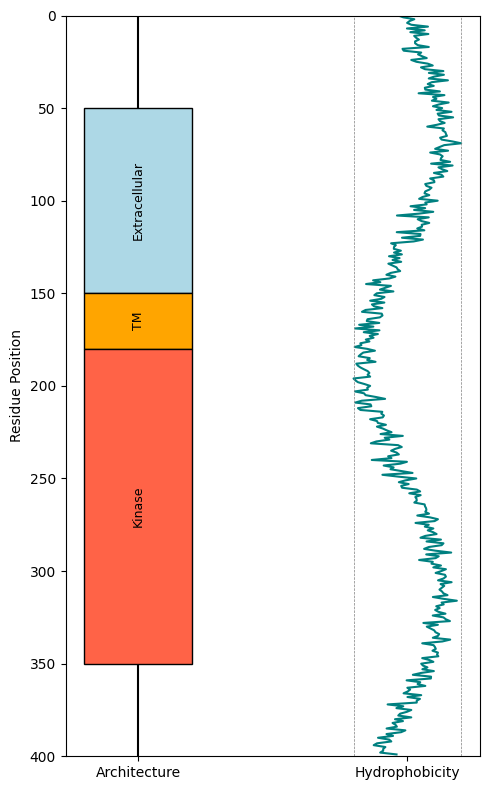

In [3]:
# 1. Create a Domain Track
domains = DomainTrack("Architecture", 400)
domains.add_domain(50, 150, "Extracellular", "lightblue")
domains.add_domain(150, 180, "TM", "orange")
domains.add_domain(180, 350, "Kinase", "tomato")

# 2. Create a Linear Track (e.g. random Hydrophobicity)
data = np.sin(np.linspace(0, 10, 400)) + np.random.normal(0, 0.2, 400)
scores = LinearTrack("Hydrophobicity", data, plot_type='line', color='teal')

# 3. Plot together
viz = ProteinPlotter()
viz.add_track(domains)
viz.add_track(scores)
viz.plot()